# **Conditional Workflow**
#### Using the example of roots of quadratic equations

In [13]:
from langgraph.graph import StateGraph,START ,END
from typing import TypedDict,Literal

In [14]:
class QuadState(TypedDict):
    
    a: int 
    b: int 
    c: int 
    
    equation: str 
    discriminant: float 
    result: str 


In [15]:
def show_equation(state: QuadState):
    
    equation = f"{state['a']}X^2 + {state['b']}X + {state['c']}"
    
    return {'equation':equation}

In [16]:
def compute_discriminant(state: QuadState):
    
    discriminant = state['b']**2 - 4*state['a']*state['c']
    
    return {'discriminant': discriminant}

In [17]:
def real_roots(state: QuadState):
    
    root1 = (-state['b'] + state['discriminant']**0.5  )/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])
    
    return {'result':f"The roots are : {root1} and {root2}"}

In [18]:
def repeated_roots(state: QuadState):
    
    root = (-state['b'] )/(2*state['a'])
    
    return {'result':f"The only root is: {root}"}

In [19]:
def no_real_roots(state: QuadState):
    
    return {'result':"The equation has no real roots"}

In [20]:
def check_condition(state: QuadState) -> Literal['real_roots','repeated_roots','no_real_roots']:
    
    if state['discriminant'] > 0: 
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'    

In [21]:
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('compute_discriminant',compute_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','compute_discriminant')

graph.add_conditional_edges('compute_discriminant',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)


workflow = graph.compile()

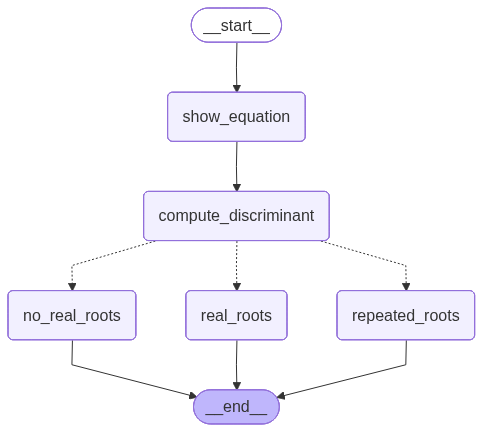

In [22]:
workflow

In [24]:
initial_state = {'a':2,'b':2,'c':2}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 2, 'b': 2, 'c': 2, 'equation': '2X^2 + 2X + 2', 'discriminant': -12, 'result': 'The equation has no real roots'}
